In [105]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

df = pd.read_csv('Combined_Data.csv')

# Which one is reference, which one is backup!?
df['FeH'] = df['FeH_vB'].fillna(df['FeH_Kr'])
df['Age'] = df['Age_vB'].fillna(df['Age_Kr'])

In [106]:
# RMS FeH error between two sets?
notfehna = (df['FeH_Kr']*df['FeH_vB']).notna()
np.sqrt(np.mean((df['FeH_Kr']-df['FeH_vB']).loc[notfehna]))

0.2324617420963319

In [107]:
# RMS age error between two sets?
notagena = (df['Age_Kr']*df['Age_vB']).notna()
np.sqrt(np.mean((df['Age_Kr']-df['Age_vB']).loc[notagena]))

0.6797906917687124

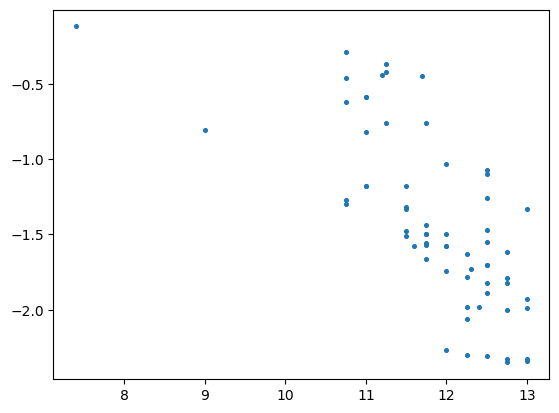

In [108]:
plt.scatter(df['Age'], df['FeH'], s=7)

In [110]:
# Sun coords
R0 = 8.2          # Sun distance from GC
U, V, W = 11.1, 250.0, 7.25  # Sun speed
l, b = np.radians(d['L']), np.radians(d['B'])

# Add the sun motion to the heliocentric los velocity
df['v_gsr'] = (df['v_r'] + U*np.cos(l)*np.cos(b) + V*np.sin(l)*np.cos(b) + W*np.sin(b))

# Radius from GC in the disk plane
df['R_cyl'] = np.sqrt(df['R_gc']**2 - df['Z']**2)

# Rotation speed per cluster: v_gsr = v_phi * (R0/R) * sin(l) * cos(b)
geom = (R0 / df['R_cyl']) * np.sin(l) * np.cos(b)
df['v_phi'] = df['v_gsr'] / geom

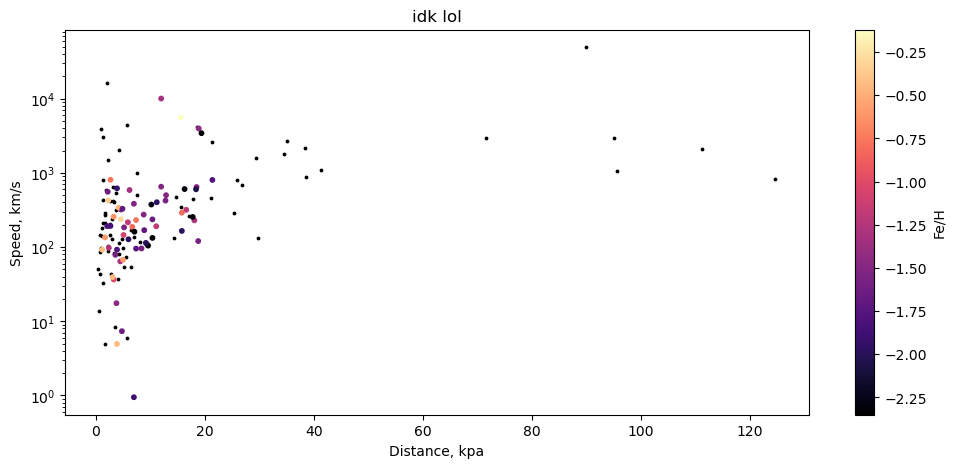

In [111]:
has_FeH = df['FeH'].notna()
plt.figure(figsize=[12, 5])
plt.scatter(df.loc[~has_FeH, 'R_gc'], np.abs(df.loc[~has_FeH, 'v_phi']), c="black", s=3)
plt.scatter(df.loc[has_FeH, 'R_gc'], np.abs(df.loc[has_FeH, 'v_phi']), c=df.loc[has_FeH, 'FeH'], cmap="magma", s=10)

plt.title('idk lol')
plt.yscale('log')
plt.xlabel('Distance, kpa')
plt.ylabel('Speed, km/s')
plt.colorbar().set_label('Fe/H')